# 05｜自主修改练习：只改一处，再找证据

目标不是找到“最强模型”，而是完成可复查的小型代码实验：基线、运行前预测、唯一修改、数值与图形证据、有限结论。

In [1]:
%matplotlib inline
from pathlib import Path
import sys
import torch

LAB_DIR = Path.cwd()
if not (LAB_DIR / "transformer_lab").is_dir():
    LAB_DIR = (LAB_DIR / "04_transformer_lab").resolve()
if str(LAB_DIR) not in sys.path:
    sys.path.insert(0, str(LAB_DIR))

torch.set_num_threads(1)

from dataclasses import replace
import matplotlib.pyplot as plt
from transformer_lab import (
    ExperimentConfig, configure_chinese_font,
    plot_training_history, print_result_table, run_experiment,
)


## 第一步：运行固定基线

第一次不要修改基线。

In [2]:
DEVICE = "cpu"
baseline_config = ExperimentConfig(
    name="基线 GELU",
    content_length=12,
    d_model=32,
    num_heads=4,
    num_layers=1,
    dim_feedforward=64,
    activation="gelu",
    epochs=12,
    seed=42,
    device=DEVICE,
)
baseline = run_experiment(baseline_config)
print_result_table([baseline])


实验                          测试Acc       参数量     更新        组合预算       秒
基线 GELU                     99.7%     8,771    228   2,433,600    0.99


## 第二步：选择一种修改路线

**参数路线：**只改 `dropout`、`dim_feedforward` 或 `num_heads` 中一项。

**代码路线：**打开 `transformer_lab/model.py`，在 `_activation()` 的 `choices` 中增加 PyTorch 已有激活函数，例如一行 `"silu": nn.SiLU()`，不要复制 Encoder 或训练循环。随后把下方名称换成新增项。

默认示例只把 GELU 改为 ReLU，保证修改前 Notebook 可以完整运行。

运行前预期： 只更换 Feed-forward 激活函数后，参数量应不变；Accuracy 是否变化要看结果。
实验                          测试Acc       参数量     更新        组合预算       秒
基线 GELU                     99.7%     8,771    228   2,433,600    0.99
修改后 ReLU                    99.7%     8,771    228   2,433,600    0.96


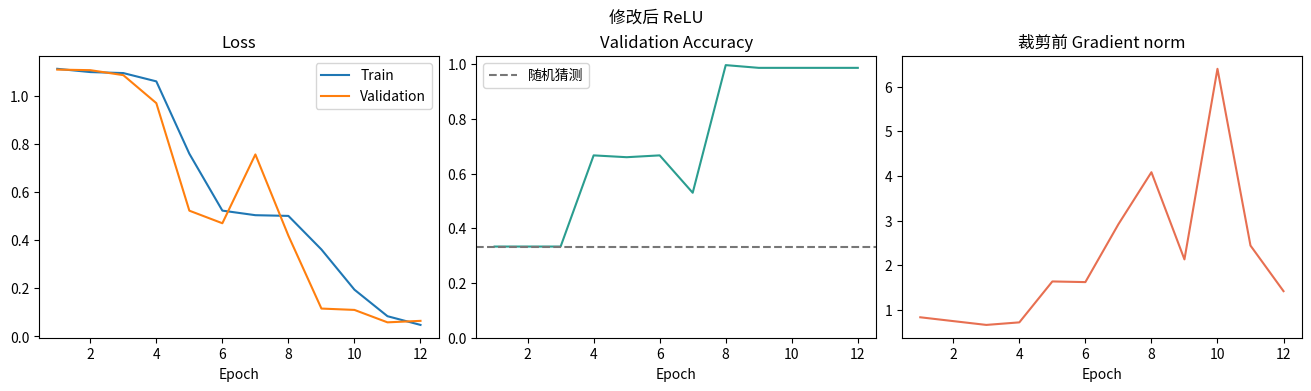

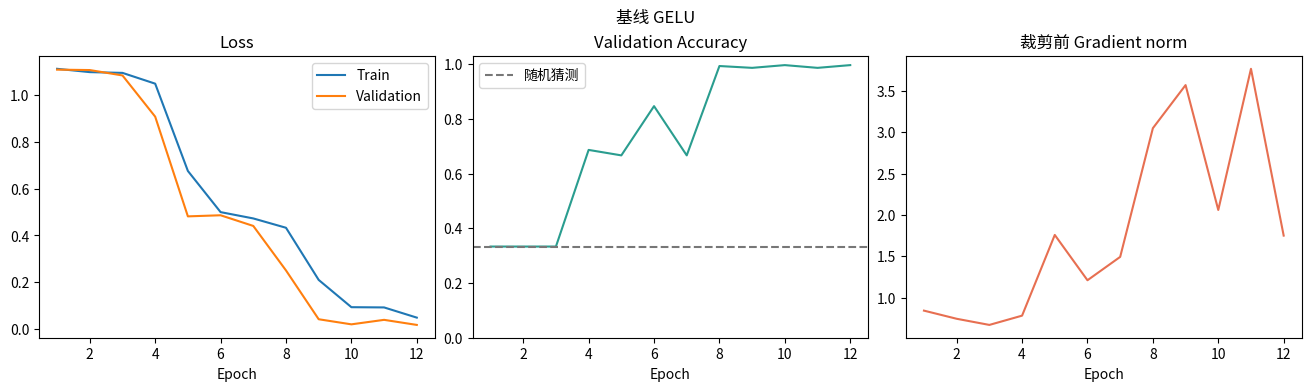

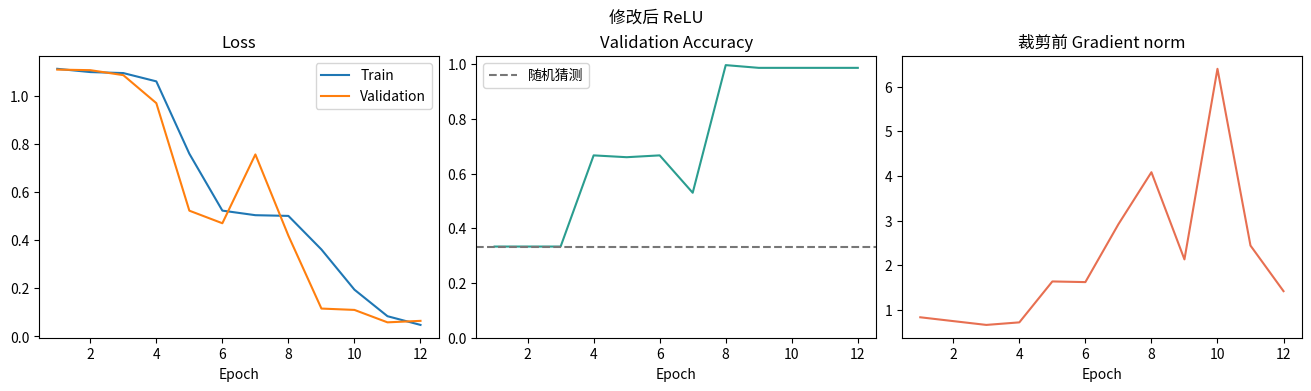

In [3]:
MY_EXPECTATION = "只更换 Feed-forward 激活函数后，参数量应不变；Accuracy 是否变化要看结果。"

changed_config = replace(
    baseline_config,
    name="修改后 ReLU",
    activation="relu",  # 完成代码路线后可换成你新增的名称
)
changed = run_experiment(changed_config)

print("运行前预期：", MY_EXPECTATION)
print_result_table([baseline, changed])
plot_training_history(baseline["history"], title=baseline_config.name)
plot_training_history(changed["history"], title=changed_config.name)


## 第三步：把差异压缩成一张证据图

运行时间只用于了解资源，不作为得分。

Text(0.5, 0.98, '一次只改一个变量')

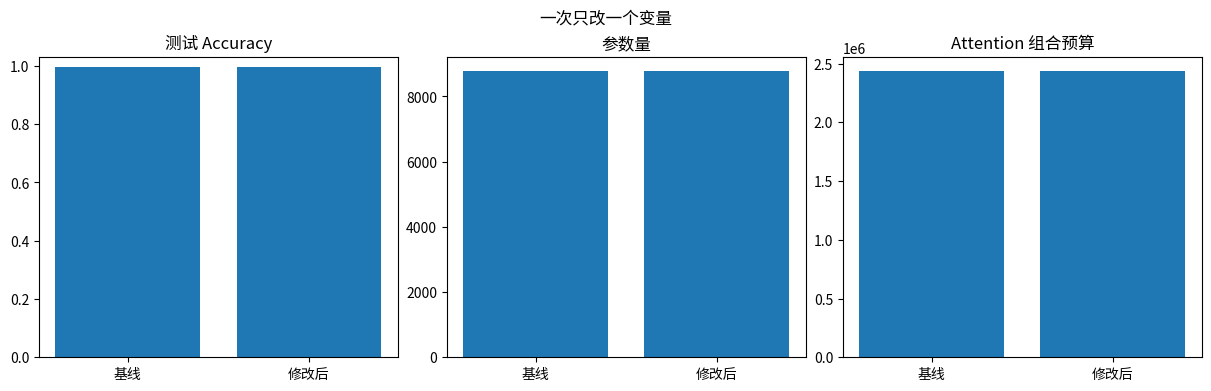

In [4]:
configure_chinese_font()
labels = ["基线", "修改后"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), constrained_layout=True)
axes[0].bar(labels, [baseline["metrics"]["accuracy"], changed["metrics"]["accuracy"]])
axes[0].set_ylim(0, 1.03); axes[0].set_title("测试 Accuracy")
axes[1].bar(labels, [baseline["parameter_count"], changed["parameter_count"]])
axes[1].set_title("参数量")
axes[2].bar(labels, [baseline["attention_budget"], changed["attention_budget"]])
axes[2].set_title("Attention 组合预算")
fig.suptitle("一次只改一个变量")


## 第四步：执行最小检查

在终端运行：

~~~bash
python test_transformer_smoke.py
~~~

保存“Transformer smoke test passed.”截图。测试失败时先恢复到基线，再检查是否只修改了映射的一行。

## 实验记录

| 项目 | 内容 |
|---|---|
| 保持不变 | 数据、seed、Epoch、模型宽度、层数等 |
| 唯一修改 |  |
| 运行前预期 |  |
| 数值证据 |  |
| 图形证据 |  |
| 测试结果 |  |
| 有边界的结论 | “在本次配置下……” |

如果同时改变 Head、层数、学习率和数据量，即使 Accuracy 提高，也无法判断原因。

## 完成本页后：释放资源并结束内核

In [ ]:
%reset -f
import gc
import matplotlib.pyplot as plt
import torch
from IPython import get_ipython

plt.close("all")
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("清理完成，正在结束当前 Notebook 的 Python 内核……")
get_ipython().kernel.do_shutdown(restart=False)
